In [1]:
!pip install google-generativeai pillow langchain-chroma

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import ollama

def ask_llm(prompt):
    response = ollama.chat(
        model="gemma3:1b",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        stream=True
    )

    for res in response:
        print(res["message"]["content"], end="", flush=True)

In [3]:
import requests
def generate_response(prompt):
    response = requests.post(
        "https://text-generation.23nm1a1210.workers.dev/",
        headers={
            "Authorization": "Bearer 12345678",
            "Content-Type": "application/json"
        },
        json={"prompt": prompt}
    )

    data = response.json()

    print(data)

    if "response" in data:
        return data["response"]

    if "error" in data:
        return f"ERROR: {data['error']}"

    return str(data)

In [4]:

from docling.document_converter import (
    DocumentConverter,
    PdfFormatOption
)
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions

pipeline_options = PdfPipelineOptions()
pipeline_options.generate_picture_images = True
pipeline_options.generate_page_images = True

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_options
        )
    }
)
PDF_PATH = r"C:/Users/trive/Downloads/AI_Report.pdf"
result = converter.convert(PDF_PATH)

doc = result.document

The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
[INFO] 2026-06-17 21:30:36,800 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-17 21:30:36,827 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\trive\AppData\Roaming\Python\Python313\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-17 21:30:36,833 [RapidOCR] main.py:65: Using C:\Users\trive\AppData\Roaming\Python\Python313\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-17 21:30:38,029 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-17 21:30:38,038 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\trive\AppData\Roaming\Python\Python313\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-17 21:30:38,040 

[PictureItem(self_ref='#/pictures/0', parent=RefItem(cref='#/body'), children=[RefItem(cref='#/texts/2')], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.PICTURE: 'picture'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=146.26577758789062, t=586.6399841308594, r=447.9601135253906, b=434.75030517578125, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 0))], source=[], comments=[], captions=[], references=[], footnotes=[], image=ImageRef(mimetype='image/png', dpi=72, size=Size(width=302.0, height=152.0), uri=AnyUrl('')), annotations=[])]
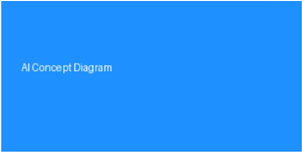

In [5]:
doc.pictures

In [6]:
print(len(doc.pictures))

1


In [7]:
from docling.chunking import HybridChunker
chunker = HybridChunker()
chunks = list(chunker.chunk(dl_doc=doc))

In [8]:
print(len(chunks))

1


In [9]:
!pip install -U google-generativeai

Defaulting to user installation because normal site-packages is not writeable


In [10]:
!pip install -U google-genai

Defaulting to user installation because normal site-packages is not writeable


In [11]:
import google.generativeai as genai
genai.configure(api_key="AQ.Ab8RN6LN_4ZW-djFljTqvLjt2_oYf_YdC41azaeHJHwlQnugFQ")
model = genai.GenerativeModel("gemini-2.5-flash")

C:\Users\trive\AppData\Local\Temp\ipykernel_11460\3695711795.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [12]:
def summarize_chunk(chunk):
    TEXT_PROMPT = f"""
Summarize the following chunk.
Preserve important names, numbers and facts.
Return only the summary.

Chunk:
{chunk}
"""
    return generate_response(TEXT_PROMPT)

In [13]:
IMAGE_PROMPT = """
Generate a comprehensive semantic description of this image for use in a multimodal retrieval system.

Describe all visible content including:
- Titles and headings
- Objects and entities
- Text and numbers
- Tables and charts
- Axes, legends and units
- Diagrams and flowcharts
- Relationships between components
- Colors and layout when important
- Statistics and measurements
- Technical terminology
- Key conclusions and insights

Preserve names, dates, values, and identifiers exactly.

Produce a detailed, self-contained description so that a user can answer questions about the image without directly seeing it.

Return only the description.
"""

In [14]:
def summarize_image(image):

    response = model.generate_content(
        [
            IMAGE_PROMPT,
            image
        ]
    )

    print(response.text)

    return response.text

In [15]:
documents = []
from langchain_core.documents import Document

In [16]:
from langchain_core.documents import Document

documents = []

for chunk in chunks:
    print("chunked")
    summary = summarize_chunk(str(chunk.text))

    documents.append(
        Document(
            page_content=summary,
            metadata={
                "type": "text"
            }
        )
    )


chunked
{'error': 'Unauthorized'}


In [17]:
import time

for picture in doc.pictures:
    image = picture.get_image(doc)

    if image is None:
        continue

    try:
        summary = summarize_image(image)

        documents.append(
            Document(
                page_content=summary,
                metadata={"type": "image"}
            )
        )

        time.sleep(5)

    except Exception as e:
        print("Error:", e)
        break

The image displays a minimalist, rectangular visual with a solid, vibrant blue background. In the upper-left quadrant of this blue background, the text "AI Concept Diagram" is prominently featured. The text is rendered in a light color, appearing white, which provides a strong contrast against the blue background, making it easily legible. There are no other graphical elements present, such as charts, graphs, tables, diagrams, flowcharts, images, or specific data visualizations. Similarly, there are no axes, legends, units, or numerical measurements visible. The overall layout is clean and serves primarily to present the title or subject identifier: "AI Concept Diagram". The image acts as a header or a placeholder for a conceptual diagram related to Artificial Intelligence, without depicting the actual diagram itself.


In [18]:
len(documents)

2

In [19]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="mixedbread-ai/mxbai-embed-large-v1",
)

In [20]:
from langchain_chroma import Chroma

vectorstore = Chroma(
    collection_name="multimodal_rag",
    persist_directory="./chroma_mragdb",
    embedding_function=embeddings
)

In [21]:
vectorstore._collection.count()

10

In [22]:
vectorstore.add_documents(documents)

['3fab9487-a3a0-4792-a501-6480b11cd2fa',
 'f28a3c65-97e8-4ba5-a34a-2c17ab642f96']

In [23]:
vectorstore._collection.count()

12

In [24]:
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k":20,
        "fetch_k":50
    }
)

In [25]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder(
    "BAAI/bge-reranker-large",
)

In [26]:
def retrieve(query, top_k=5):

    docs = retriever.invoke(query)

    pairs = [
        [query, doc.page_content]
        for doc in docs
    ]

    scores = reranker.predict(pairs)

    ranked_docs = sorted(
        zip(scores, docs),
        key=lambda x: x[0],
        reverse=True
    )

    return [
        doc
        for score, doc in ranked_docs[:top_k]
    ]

In [27]:
def build_context(query):

    retrieved_docs = retrieve(query)

    context = "\n\n".join(
        doc.page_content
        for doc in retrieved_docs
    )

    return context

In [28]:
import requests

def generate_response(prompt):

    response = requests.post(
        "https://myai.ganiisunkara.workers.dev",
        headers={
            "Authorization": "Bearer 12345678",
            "Content-Type": "application/json"
        },
        json={
            "prompt": prompt
        }
    )

    return response.json()

In [29]:
def ask(query):

    context = build_context(query)
    print(f"The context retrived is:{context}")

    prompt = f"""
You are a helpful assistant.

Answer the question using ONLY the context below.

If the answer is not present, say:
'I could not find the answer in the provided context.'

Context:
{context}

Question:
{query}

Answer:
"""

    return generate_response(prompt)

In [30]:
answer = ask(
    "What is the problem statement gimme in a single line"
)

print(answer)

The context retrived is:The image displays a minimalist, rectangular visual with a solid, vibrant blue background. In the upper-left quadrant of this blue background, the text "AI Concept Diagram" is prominently featured. The text is rendered in a light color, appearing white, which provides a strong contrast against the blue background, making it easily legible. There are no other graphical elements present, such as charts, graphs, tables, diagrams, flowcharts, images, or specific data visualizations. Similarly, there are no axes, legends, units, or numerical measurements visible. The overall layout is clean and serves primarily to present the title or subject identifier: "AI Concept Diagram". The image acts as a header or a placeholder for a conceptual diagram related to Artificial Intelligence, without depicting the actual diagram itself.

The image displays a simple, rectangular graphic dominated by a solid, vibrant blue background. Positioned in the upper-left quadrant of this blu

In [31]:
from transformers import AutoTokenizer
from docling.chunking import HybridChunker

tokenizer = AutoTokenizer.from_pretrained(
    "sentence-transformers/all-MiniLM-L6-v2"
)

In [32]:
chunker = HybridChunker(
    tokenizer=tokenizer,
    max_tokens=1024
)

chunks = list(chunker.chunk(dl_doc=doc))

In [33]:
len(chunks)

1

In [34]:
from langchain_text_splitters import RecursiveCharacterTextSplitter


splitter = RecursiveCharacterTextSplitter(
    chunk_size=3000,
    chunk_overlap=600
)

docs = []

for chunk in chunks:
    docs.extend(
        splitter.create_documents(
            [chunk.text]
        )
    )

In [35]:
len(docs)

1

In [36]:
docs[0]

Document(metadata={}, page_content='Artificial Intelligence (AI) is a branch of computer science that focuses on creating machines capable of performing tasks that typically require human intelligence such as learning, reasoning, and decision making.\nType, 1 = Description. Narrow AI, 1 = Performs specific tasks like voice assistants. General AI, 1 = Human-like intelligence (theoretical). Super AI, 1 = Smarter than humans (future concept)')